<a href="https://colab.research.google.com/github/Yeldigr/Brazil/blob/here_we_go_again/Copy_of_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Local Inference on GPU
Model page: https://huggingface.co/Ultralytics/YOLOv8

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/Ultralytics/YOLOv8)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [2]:
!nvidia-smi

Thu Aug 28 10:23:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.8 MB/s eta 0:00:00


# Installation

In [2]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.3.187 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.4/112.6 GB disk)

OS                     Linux-6.1.123+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.11
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   39.4/112.6 GB
CPU                    Intel Xeon 2.00GHz
CPU count              2
GPU                    Tesla T4, 15095MiB
GPU count              1
CUDA                   12.6

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.12.0.88>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.2>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.1>=1.4.1
torch                  ✅ 2.8.0+cu126>=1.8.0
torch                  ✅ 2.8.0+cu126!=2.4.0,>=1.8.0; sys_platform == "win32"
torchv

# Training on Custom Dataset (DeepPCB)

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="46pFbGo1pChnB7qUgLMj")
project = rf.workspace("pcb-defect-1s8mf").project("deeppcb-4dhir-2tvif")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [5]:
!yolo task=detect mode=train model=yolov8m.pt data=/content/DeepPCB-1/data.yaml epochs=20 imgsz=640

New https://pypi.org/project/ultralytics/8.3.188 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.187 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DeepPCB-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=Fal

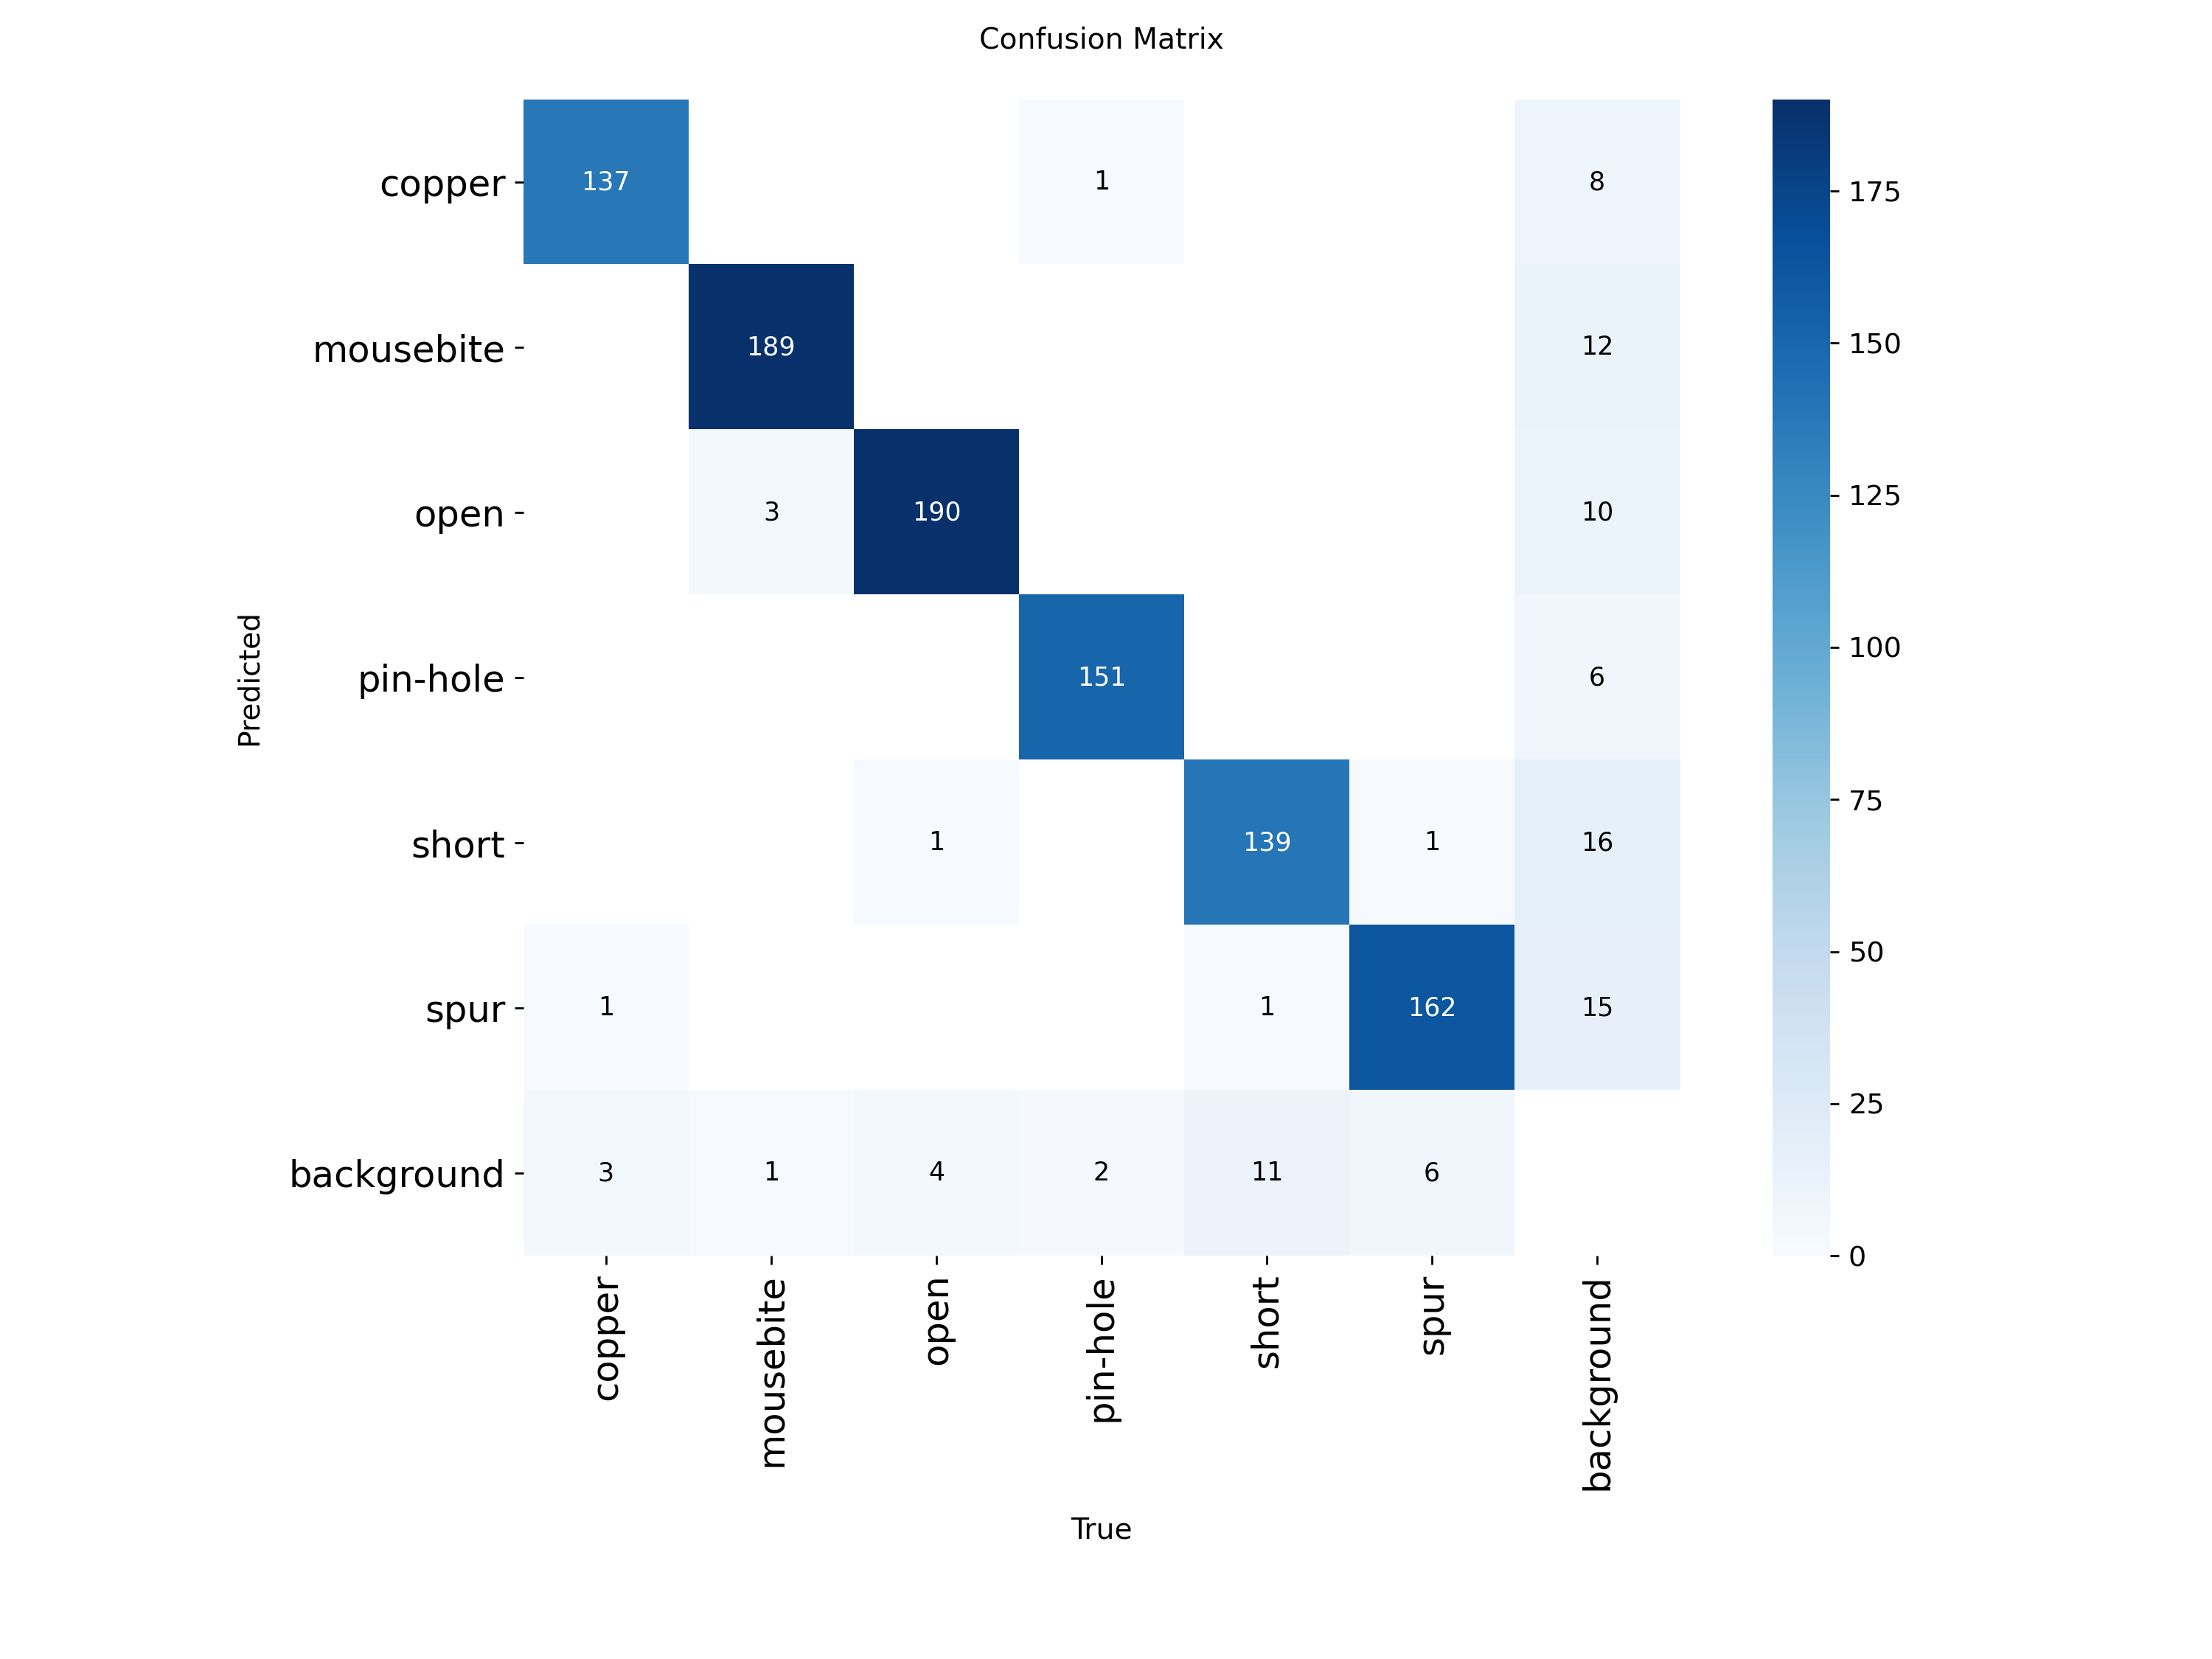

In [8]:
Image(filename='/content/runs/detect/train2/confusion_matrix.png', width=600)

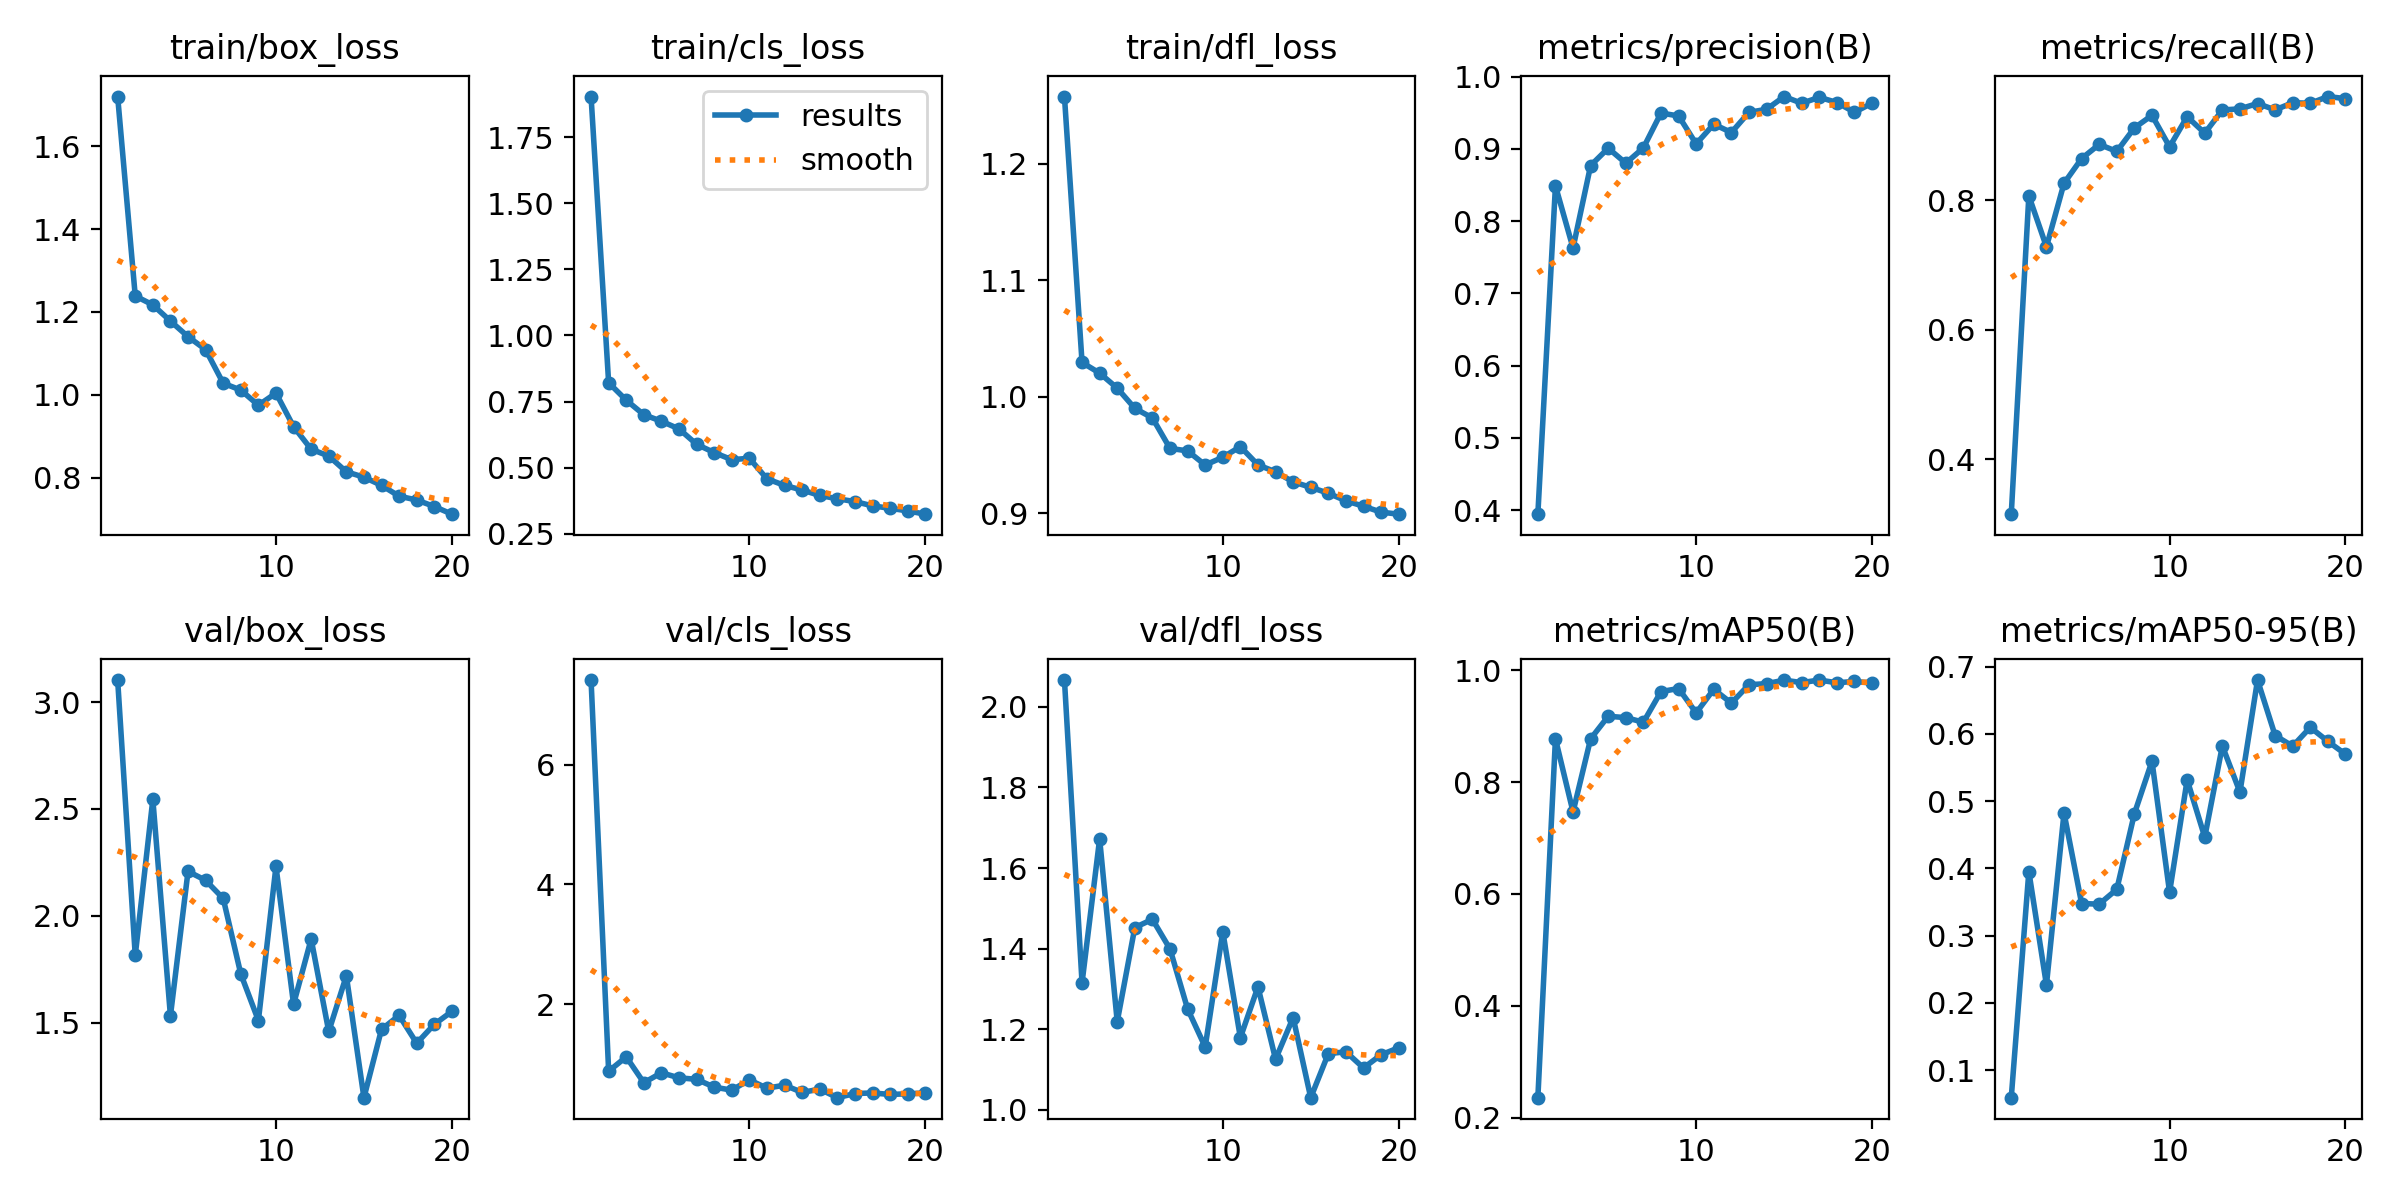

In [9]:
Image(filename=f'/content/runs/detect/train2/results.png', width=600)

In [10]:
!yolo task=detect mode=val model=/content/runs/detect/train2/weights/best.pt data=/content/DeepPCB-1/data.yaml

Ultralytics 8.3.187 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1098.2±245.4 MB/s, size: 38.2 KB)
val: Scanning /content/DeepPCB-1/valid/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 2981732.7it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.8it/s 5.5s
                   all        150       1003      0.973      0.949      0.982      0.681
                copper        118        141      0.986      0.964      0.992      0.766
             mousebite        123        193      0.995      0.954      0.994      0.709
                  open        136        195      0.984      0.965      0.989      0.628
              pin-hole        138        154      0.978      0.981      0.993      0.758
                 short        114        

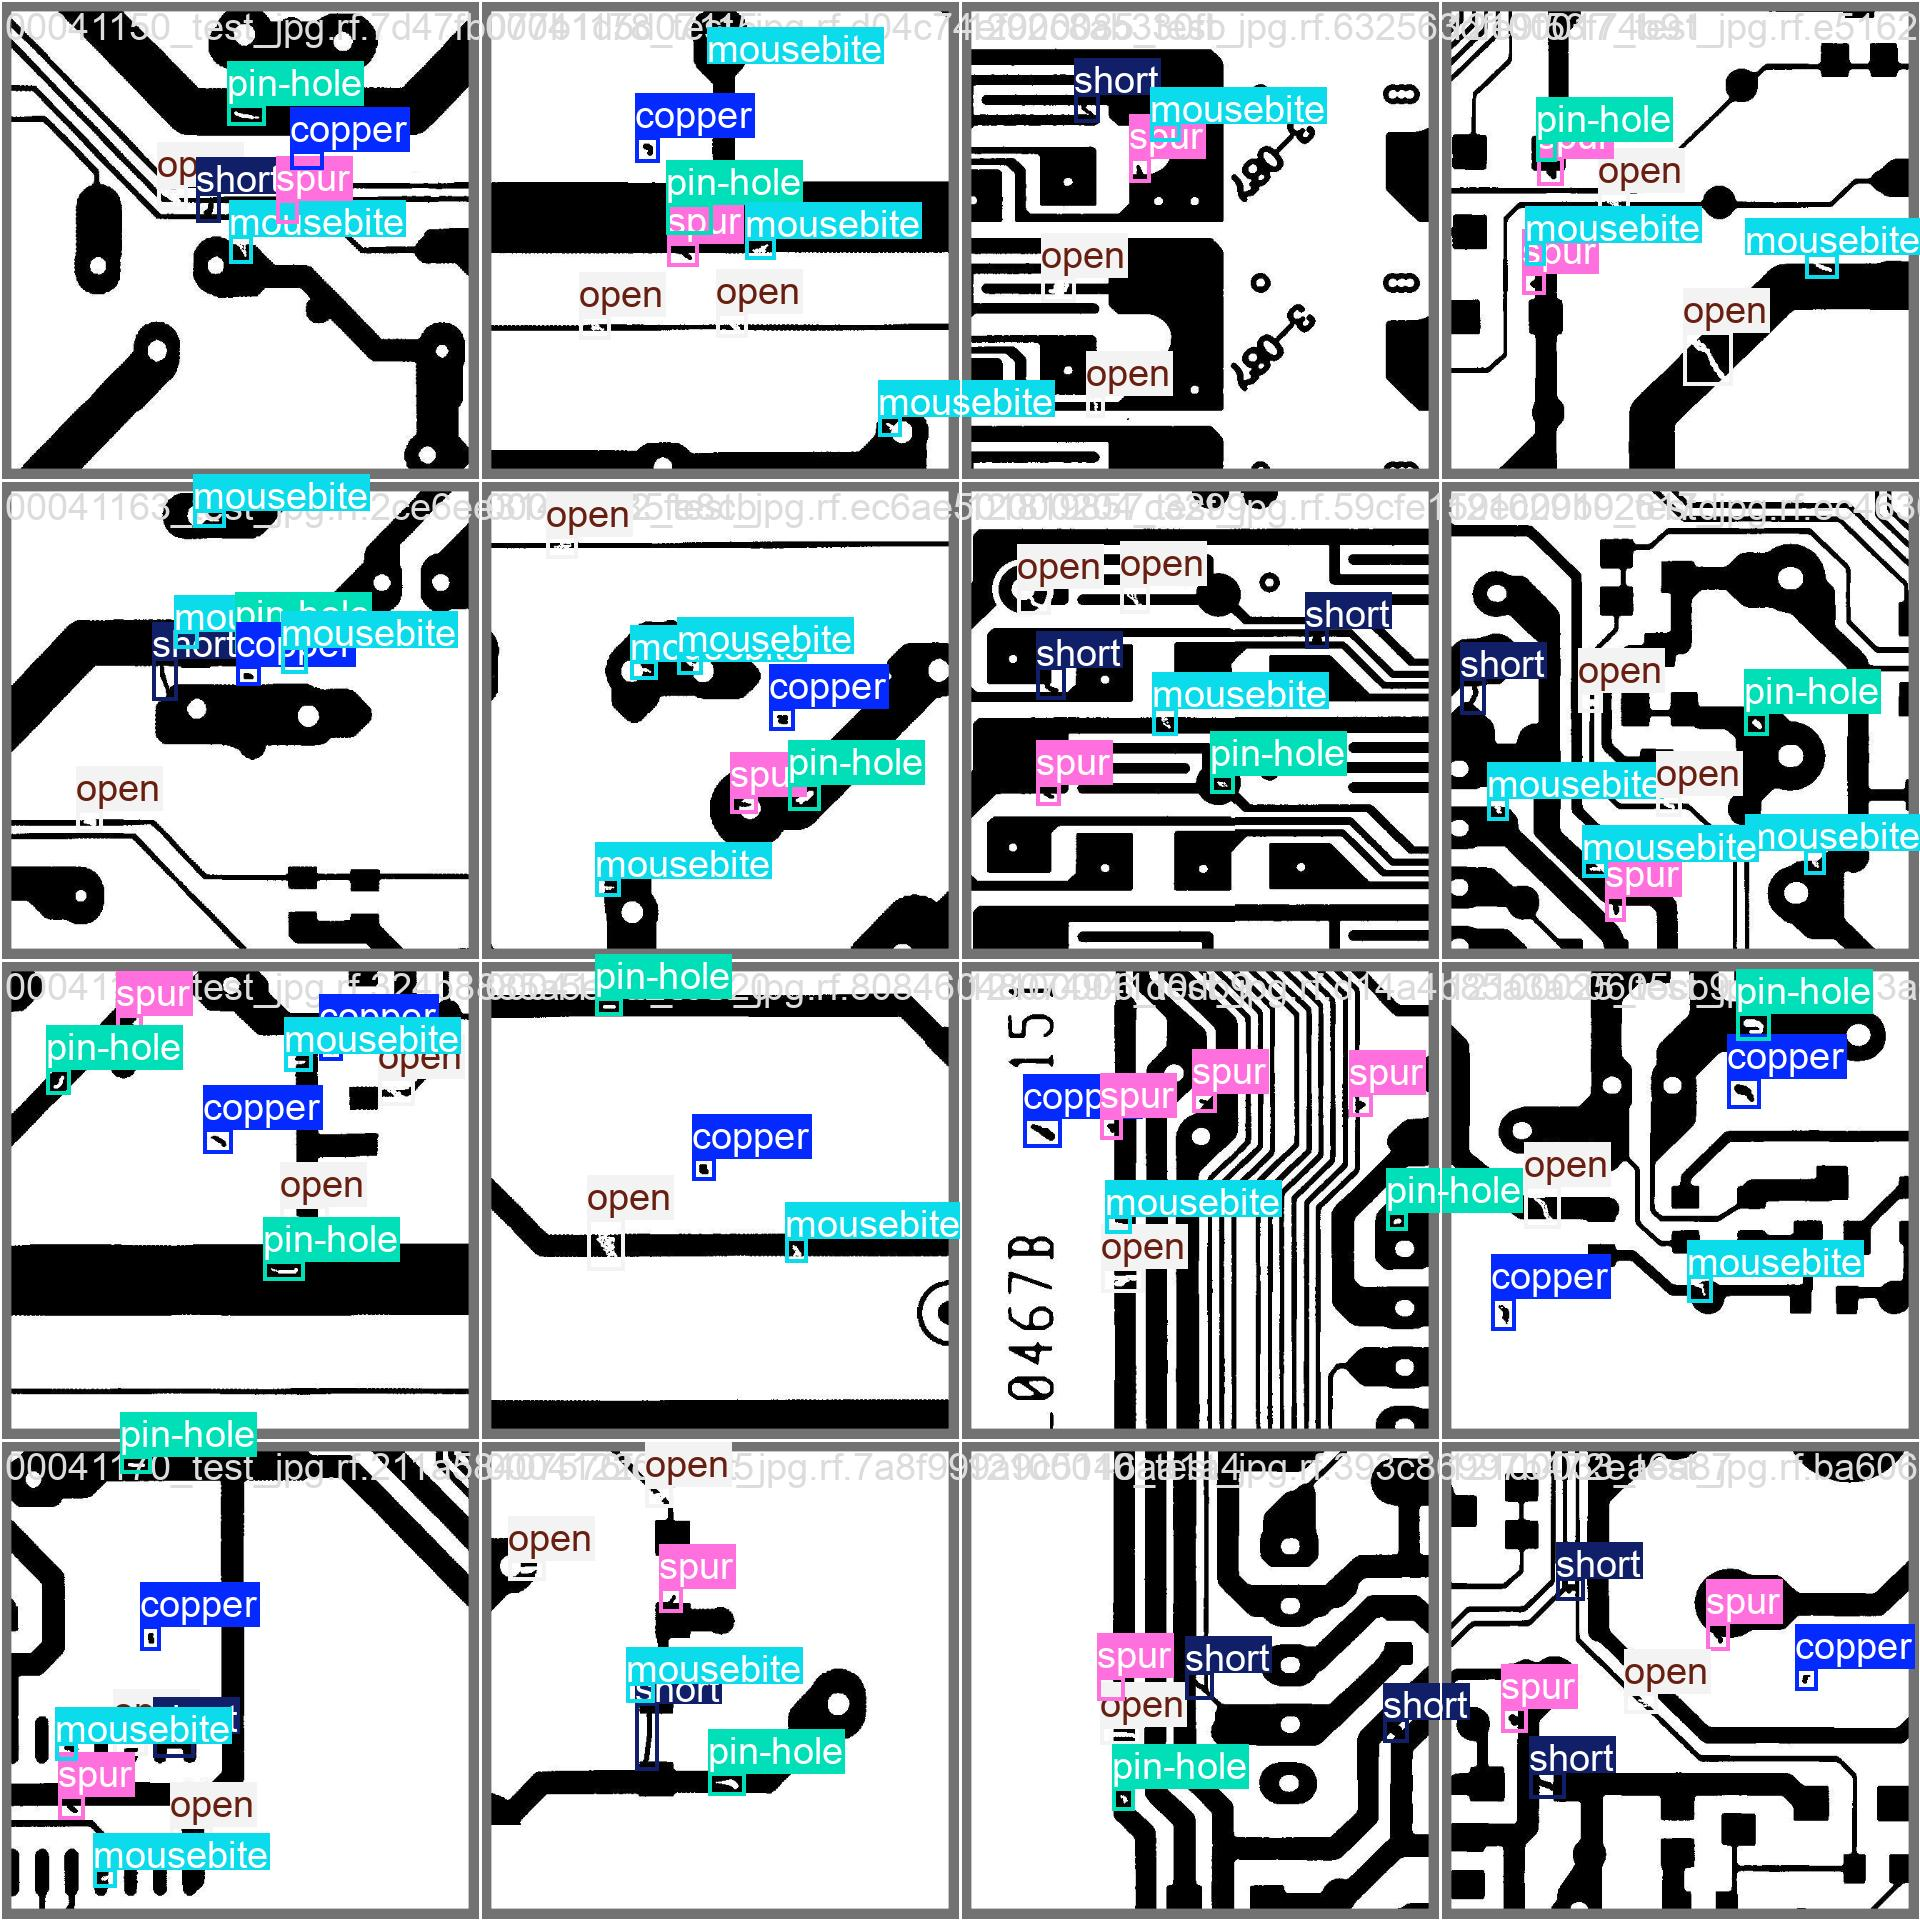

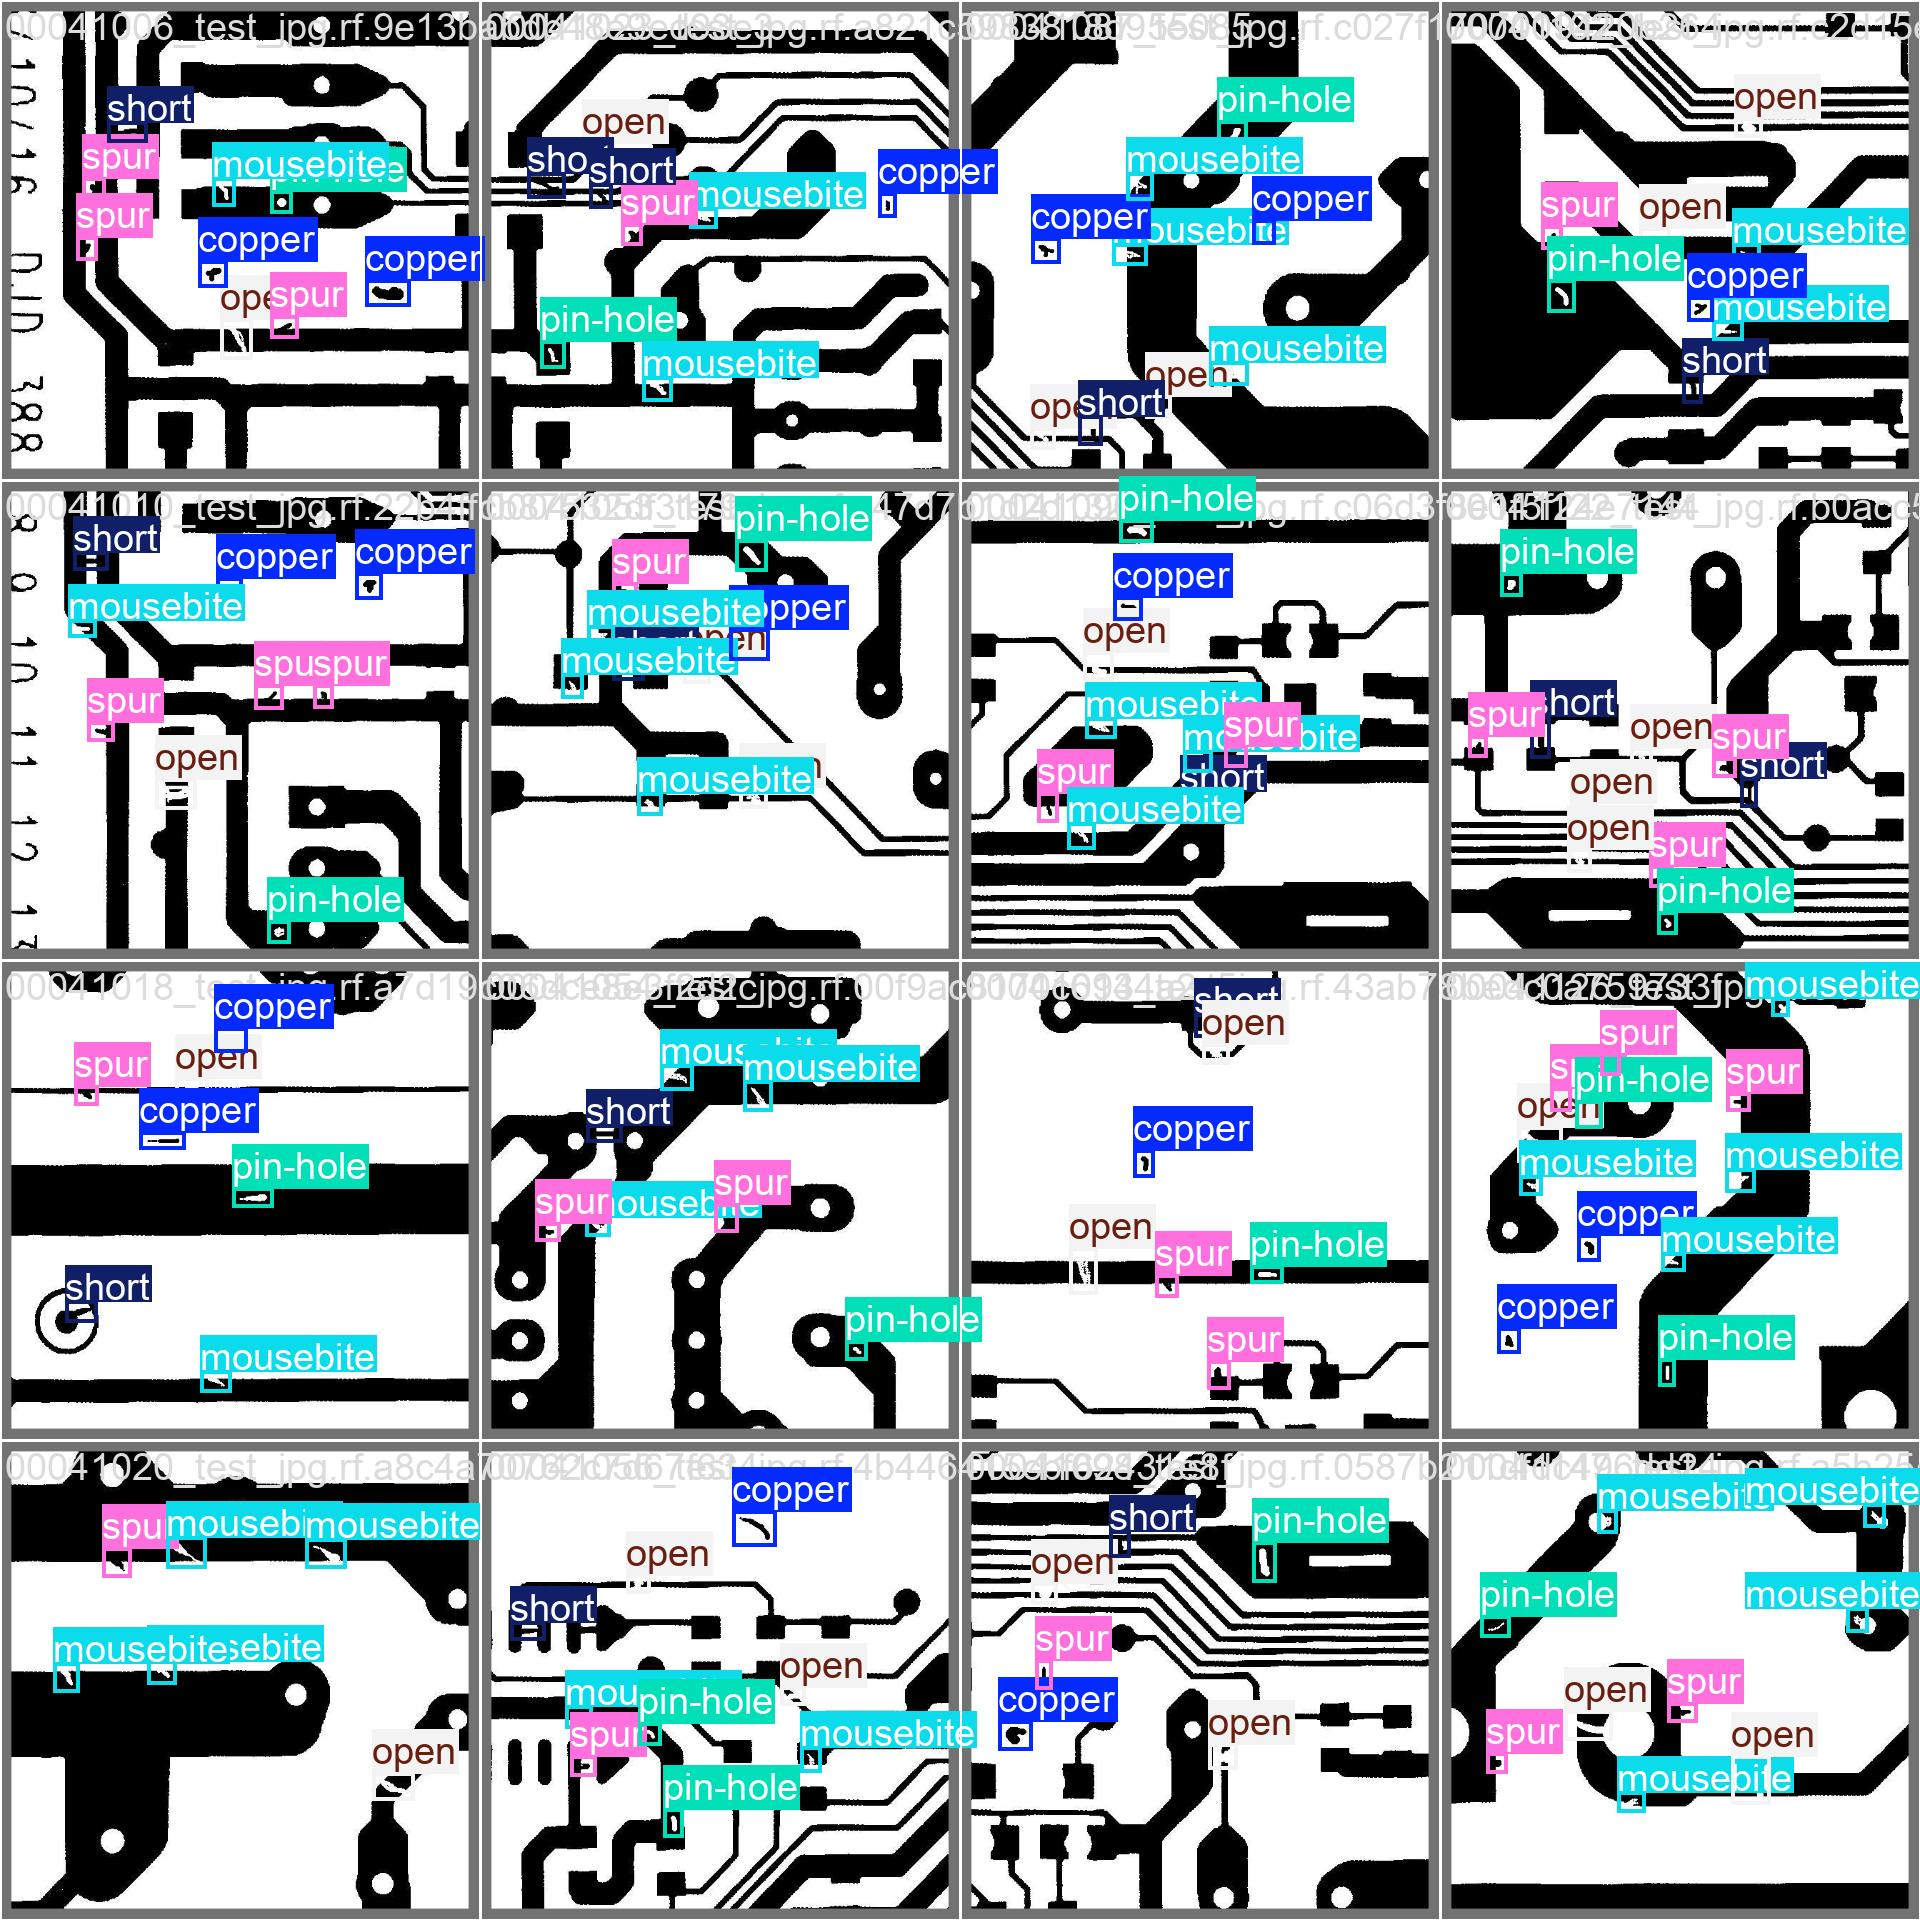

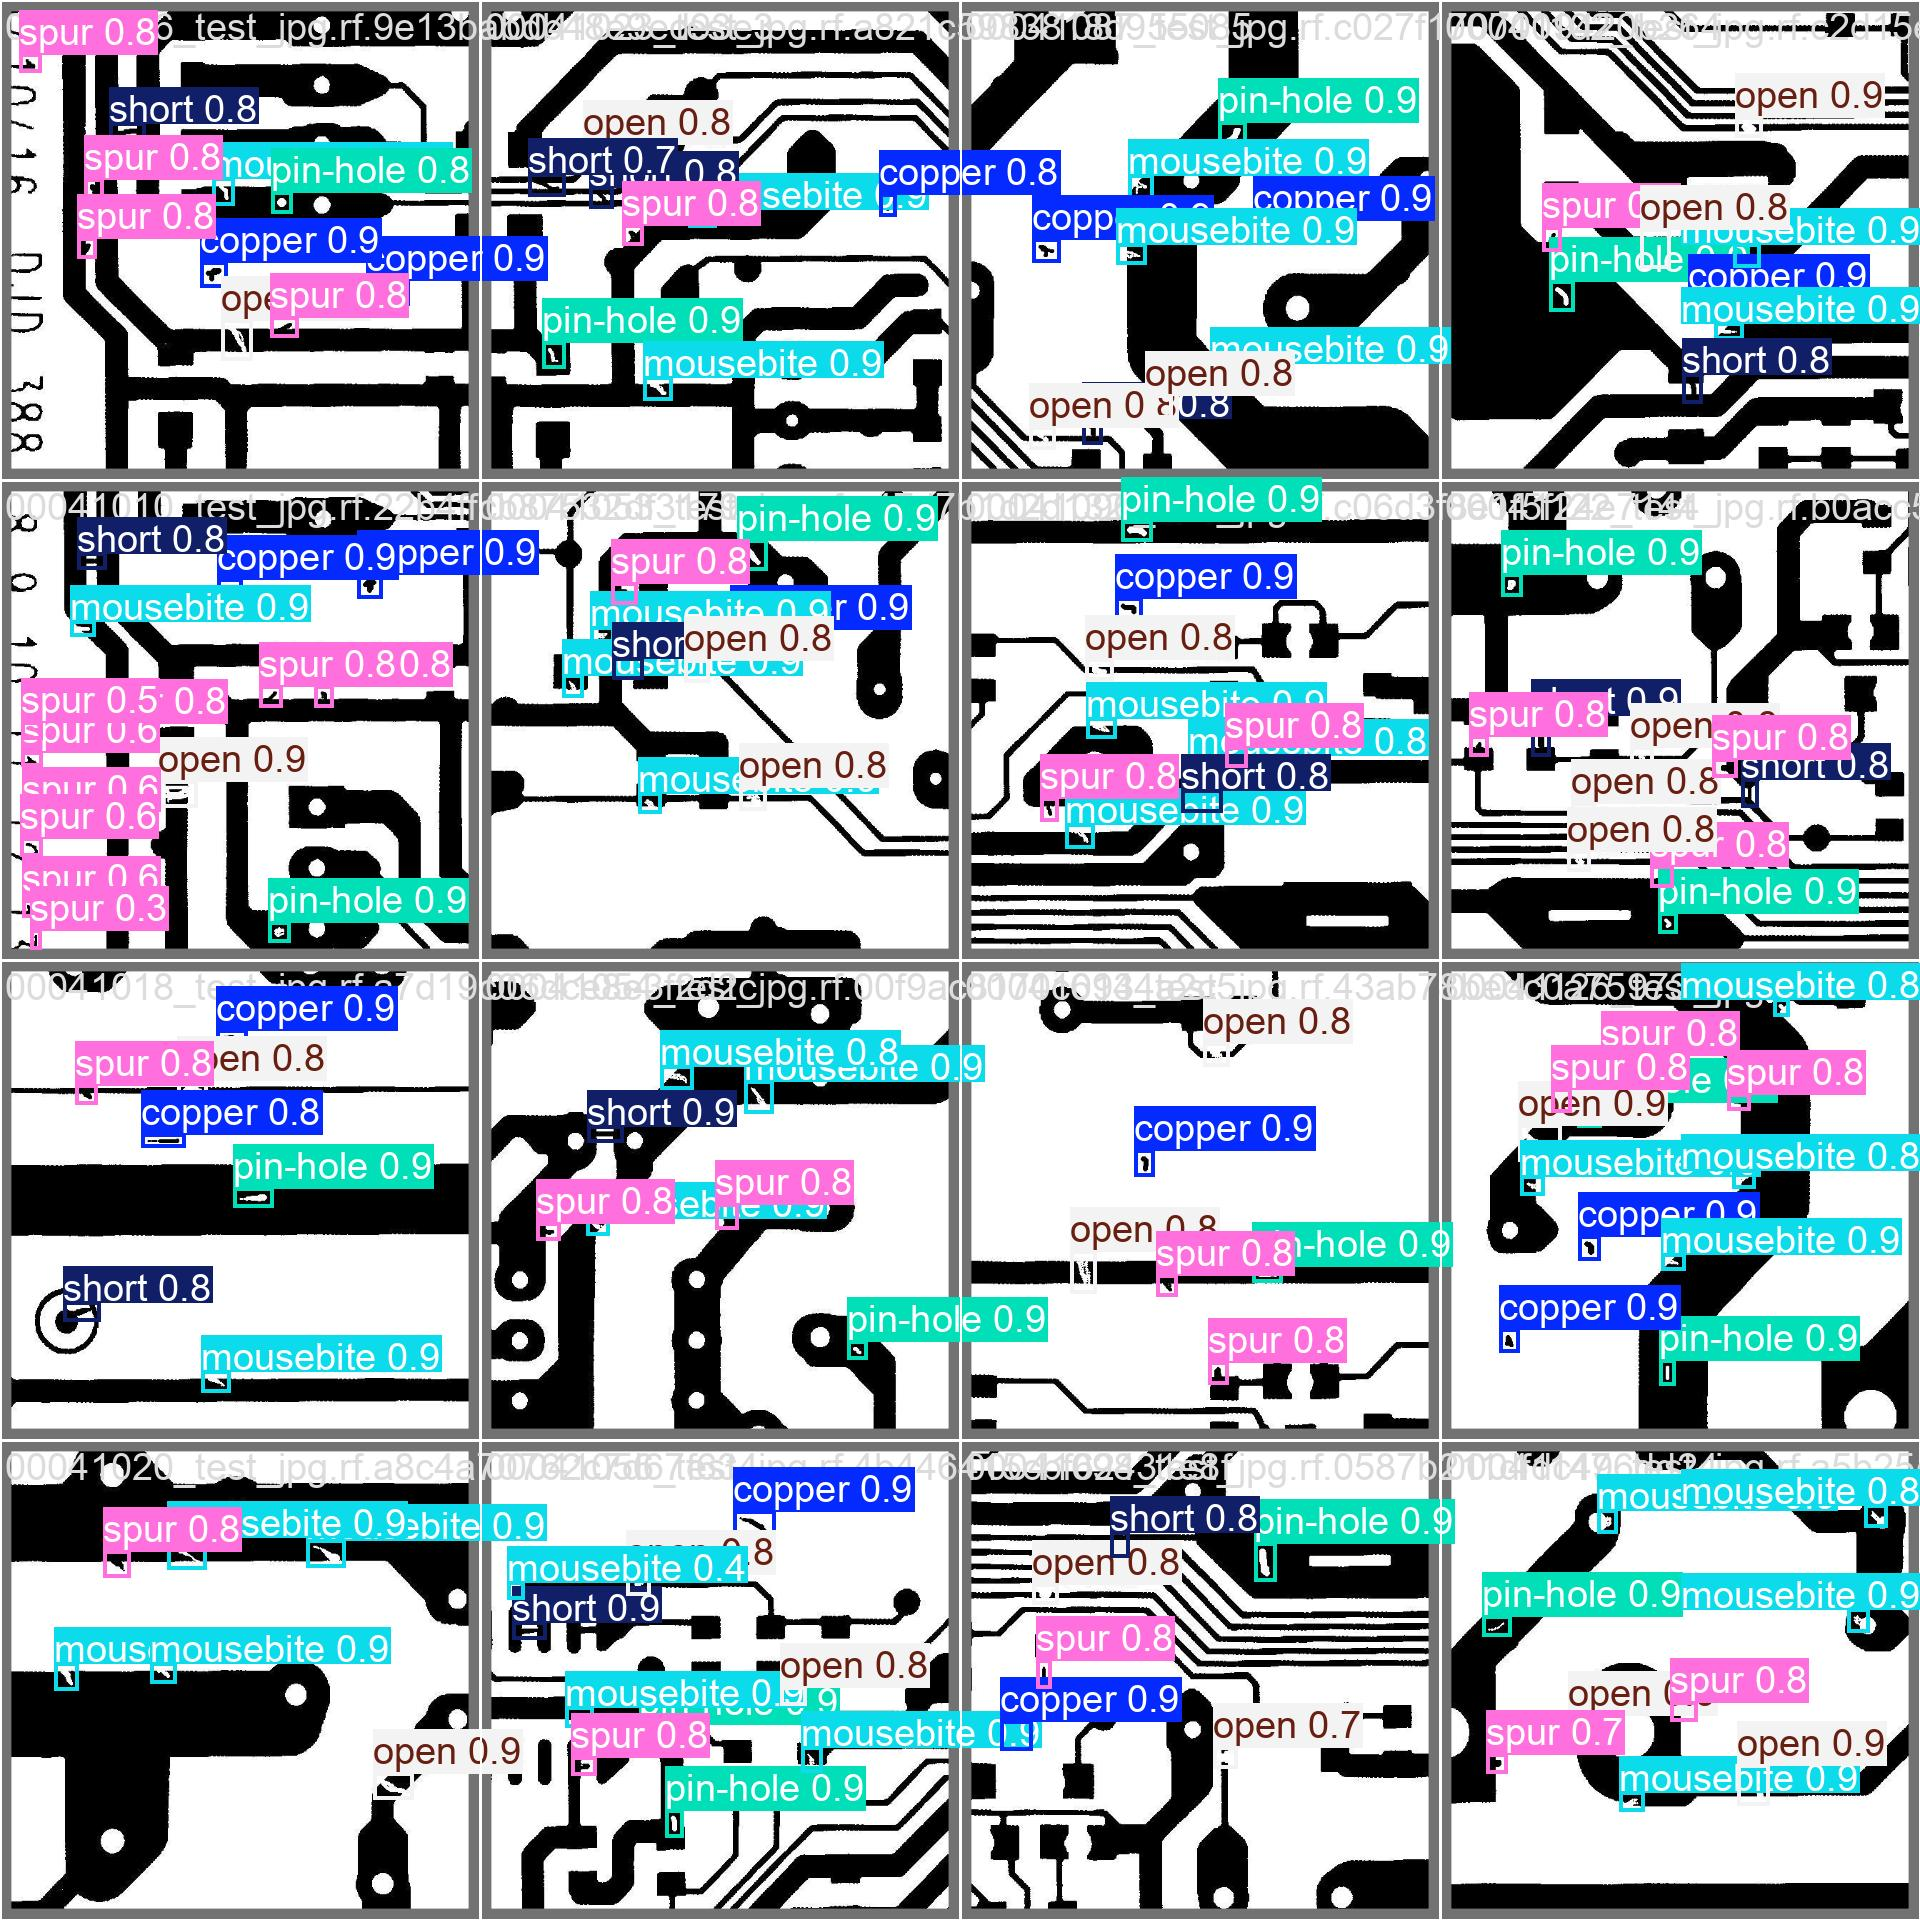

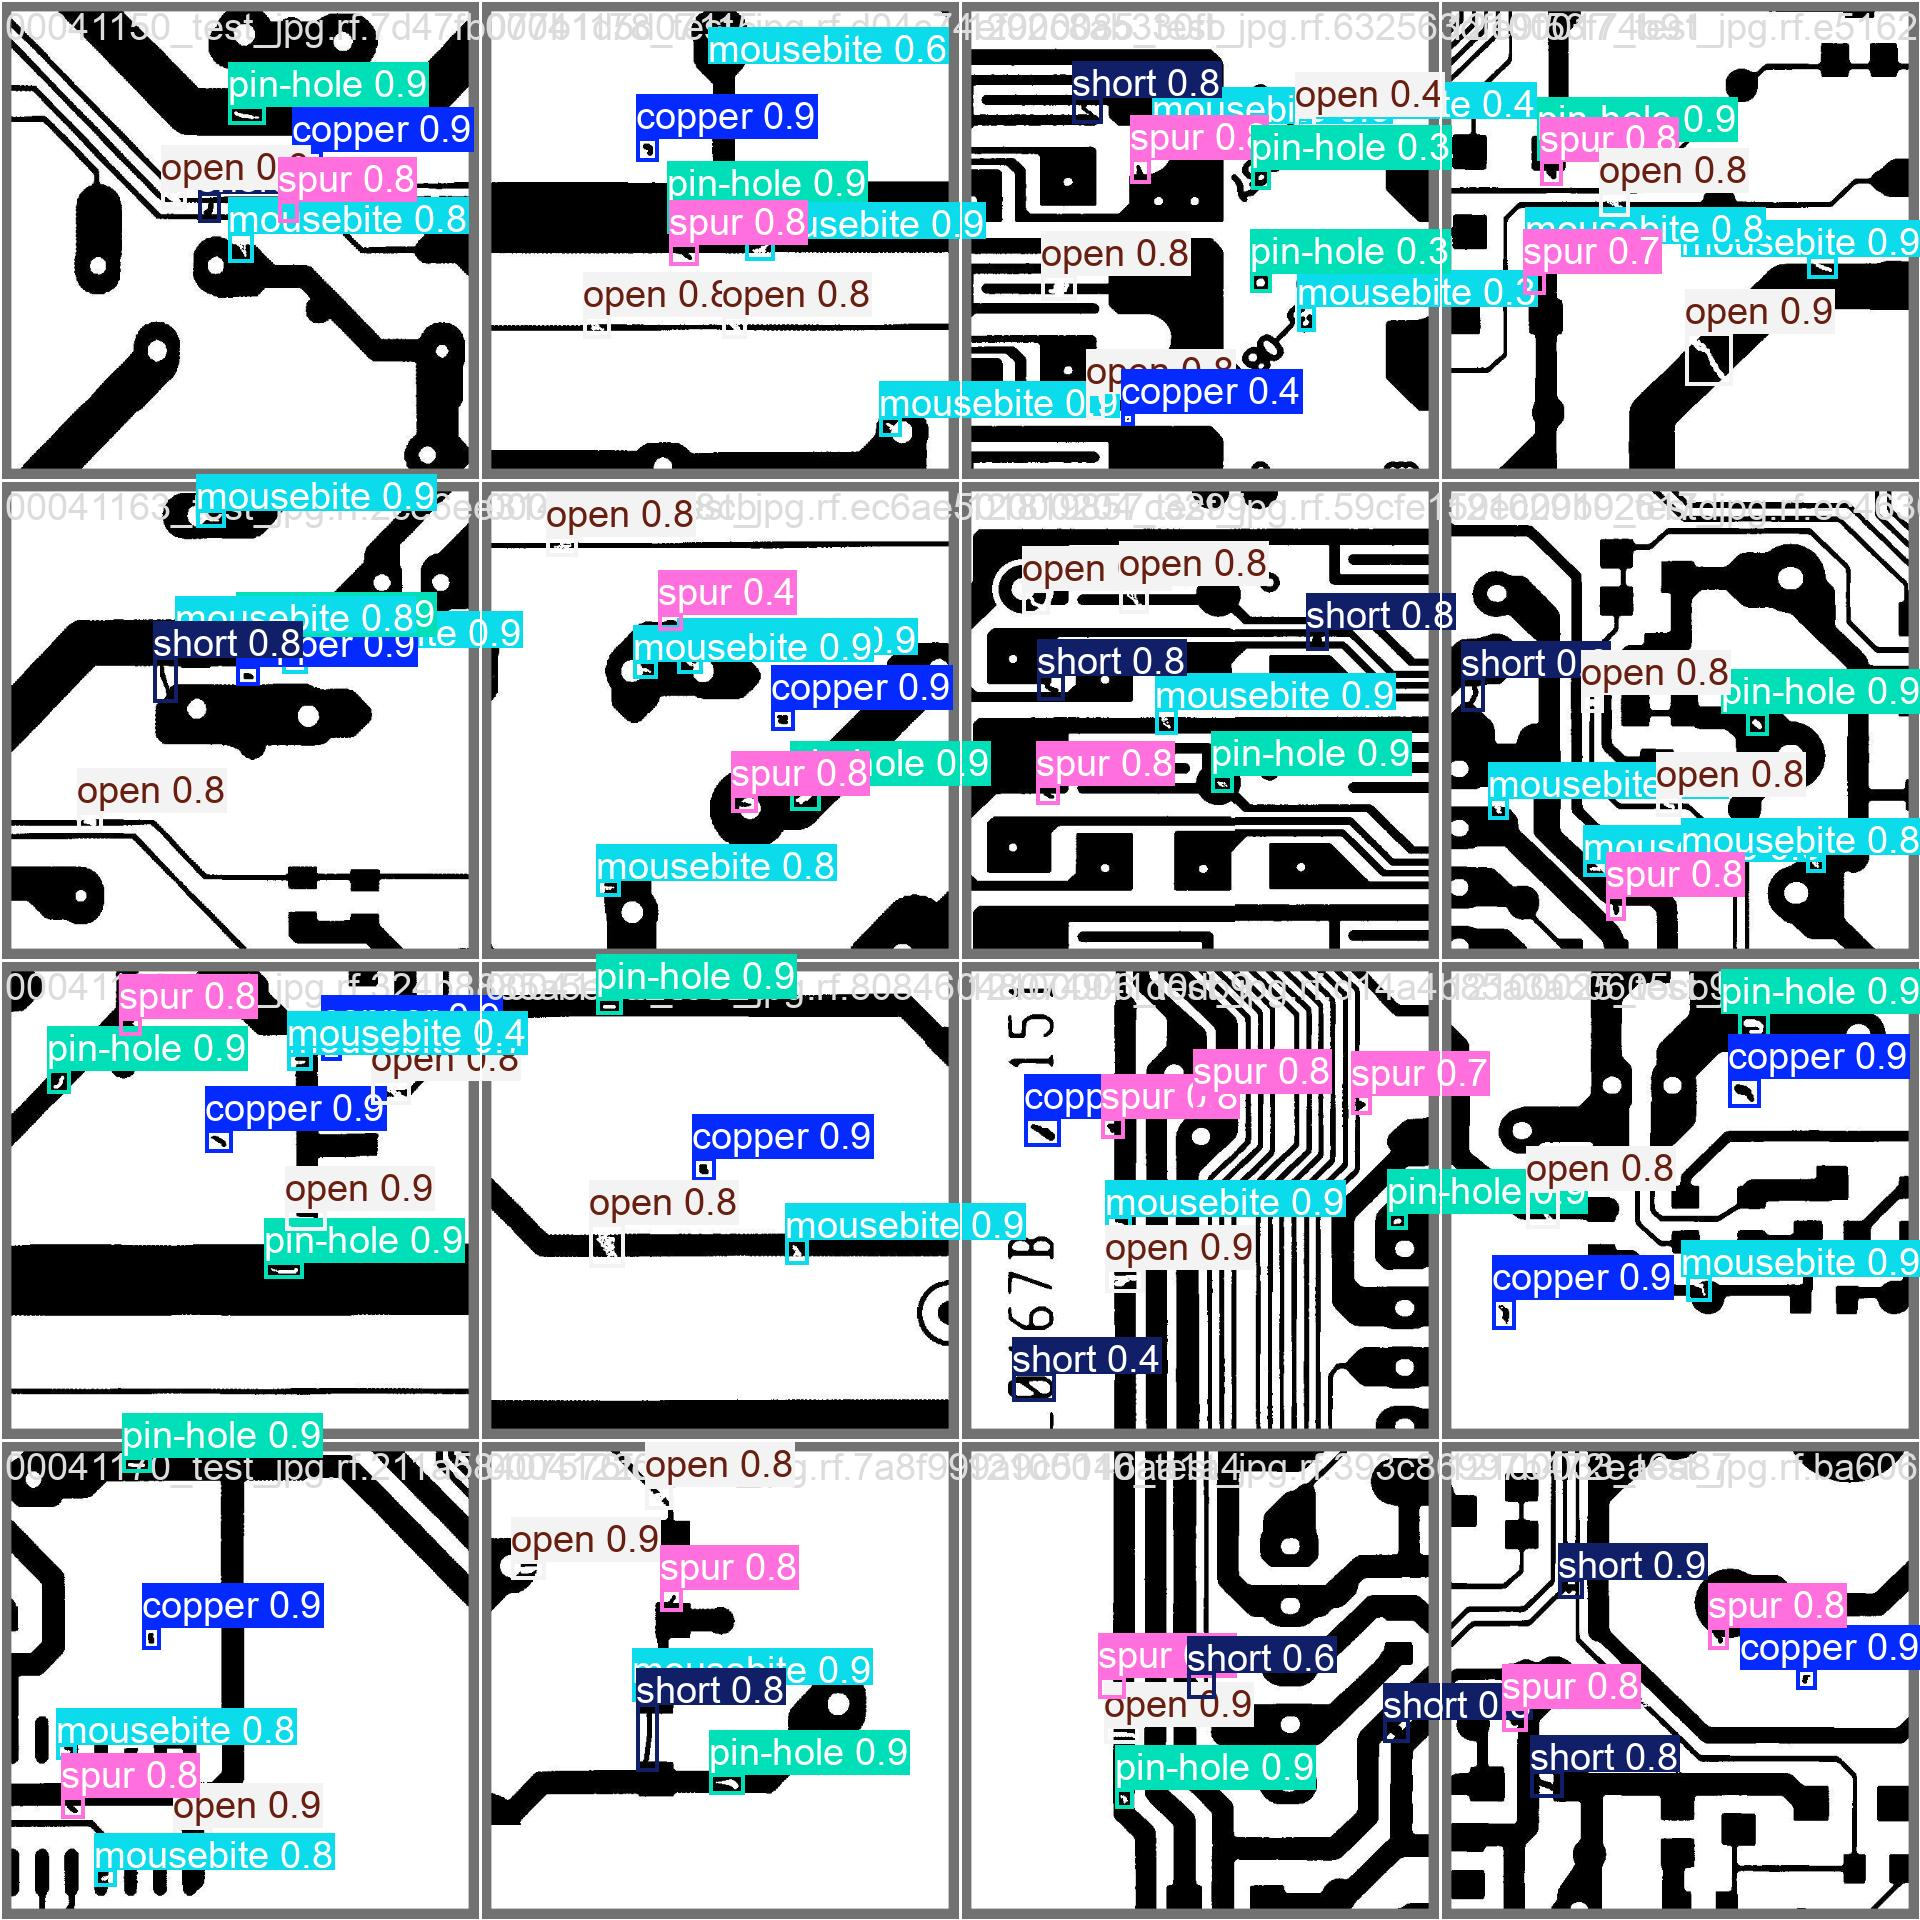

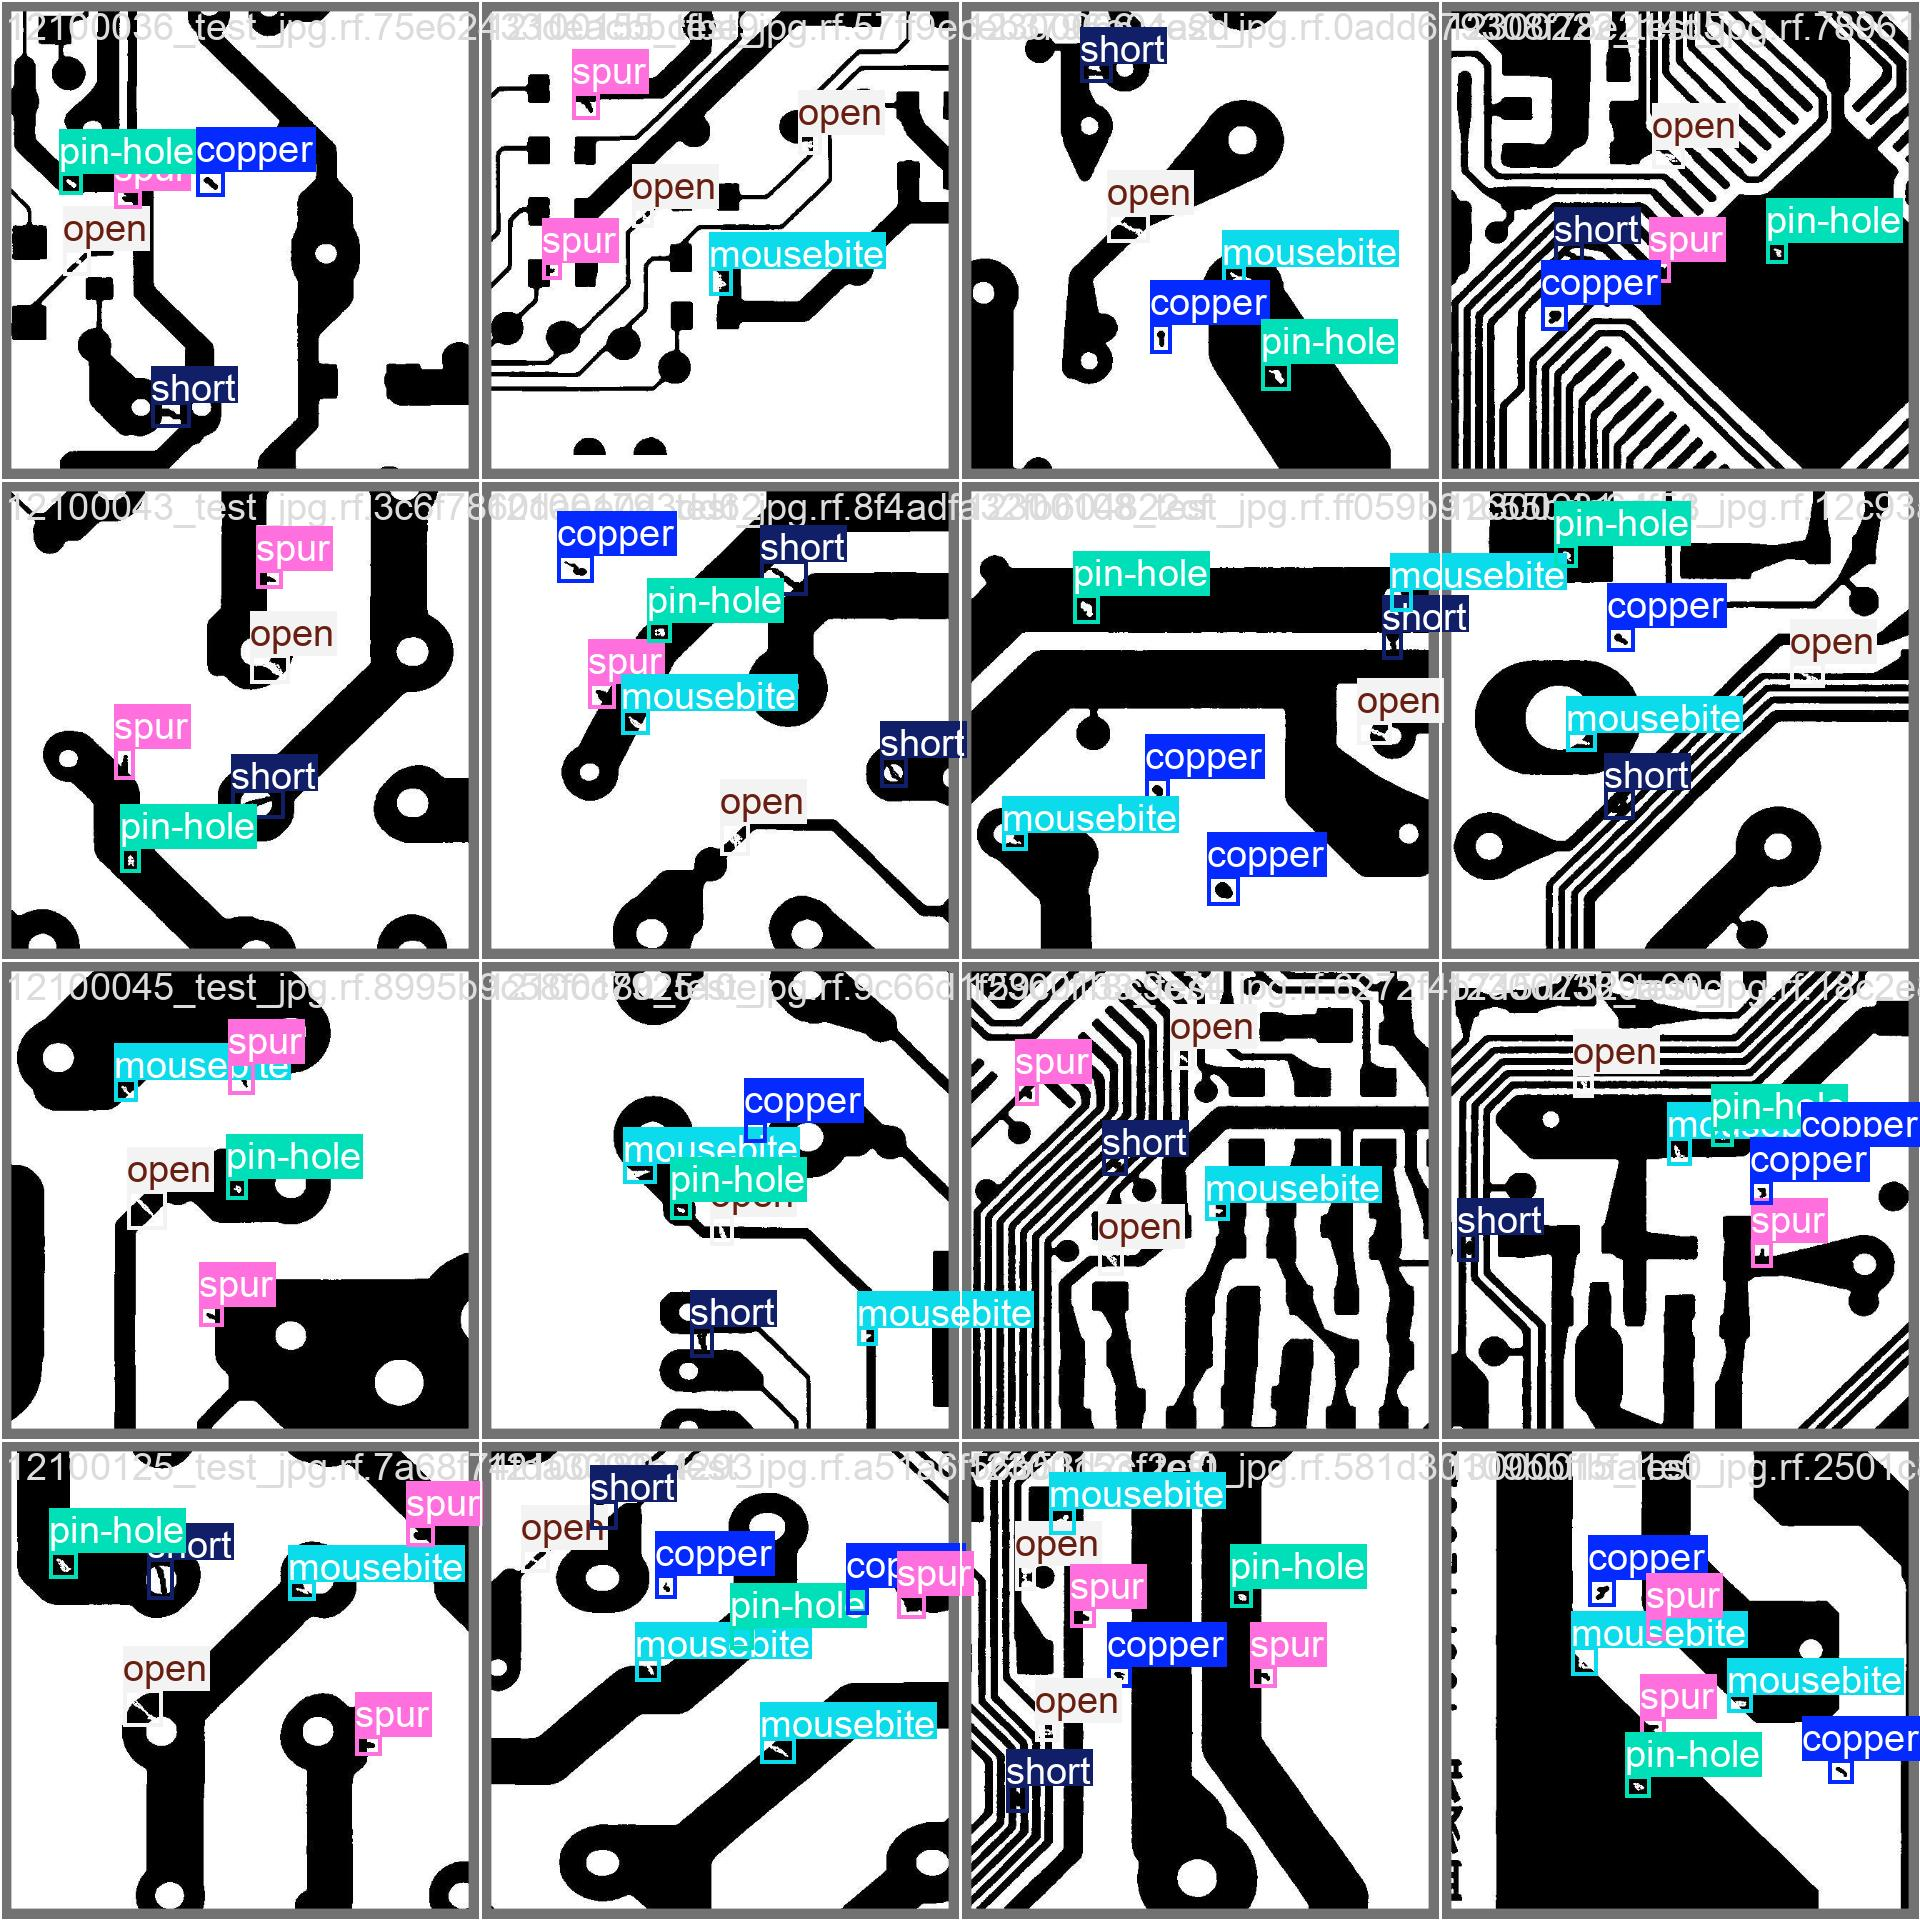

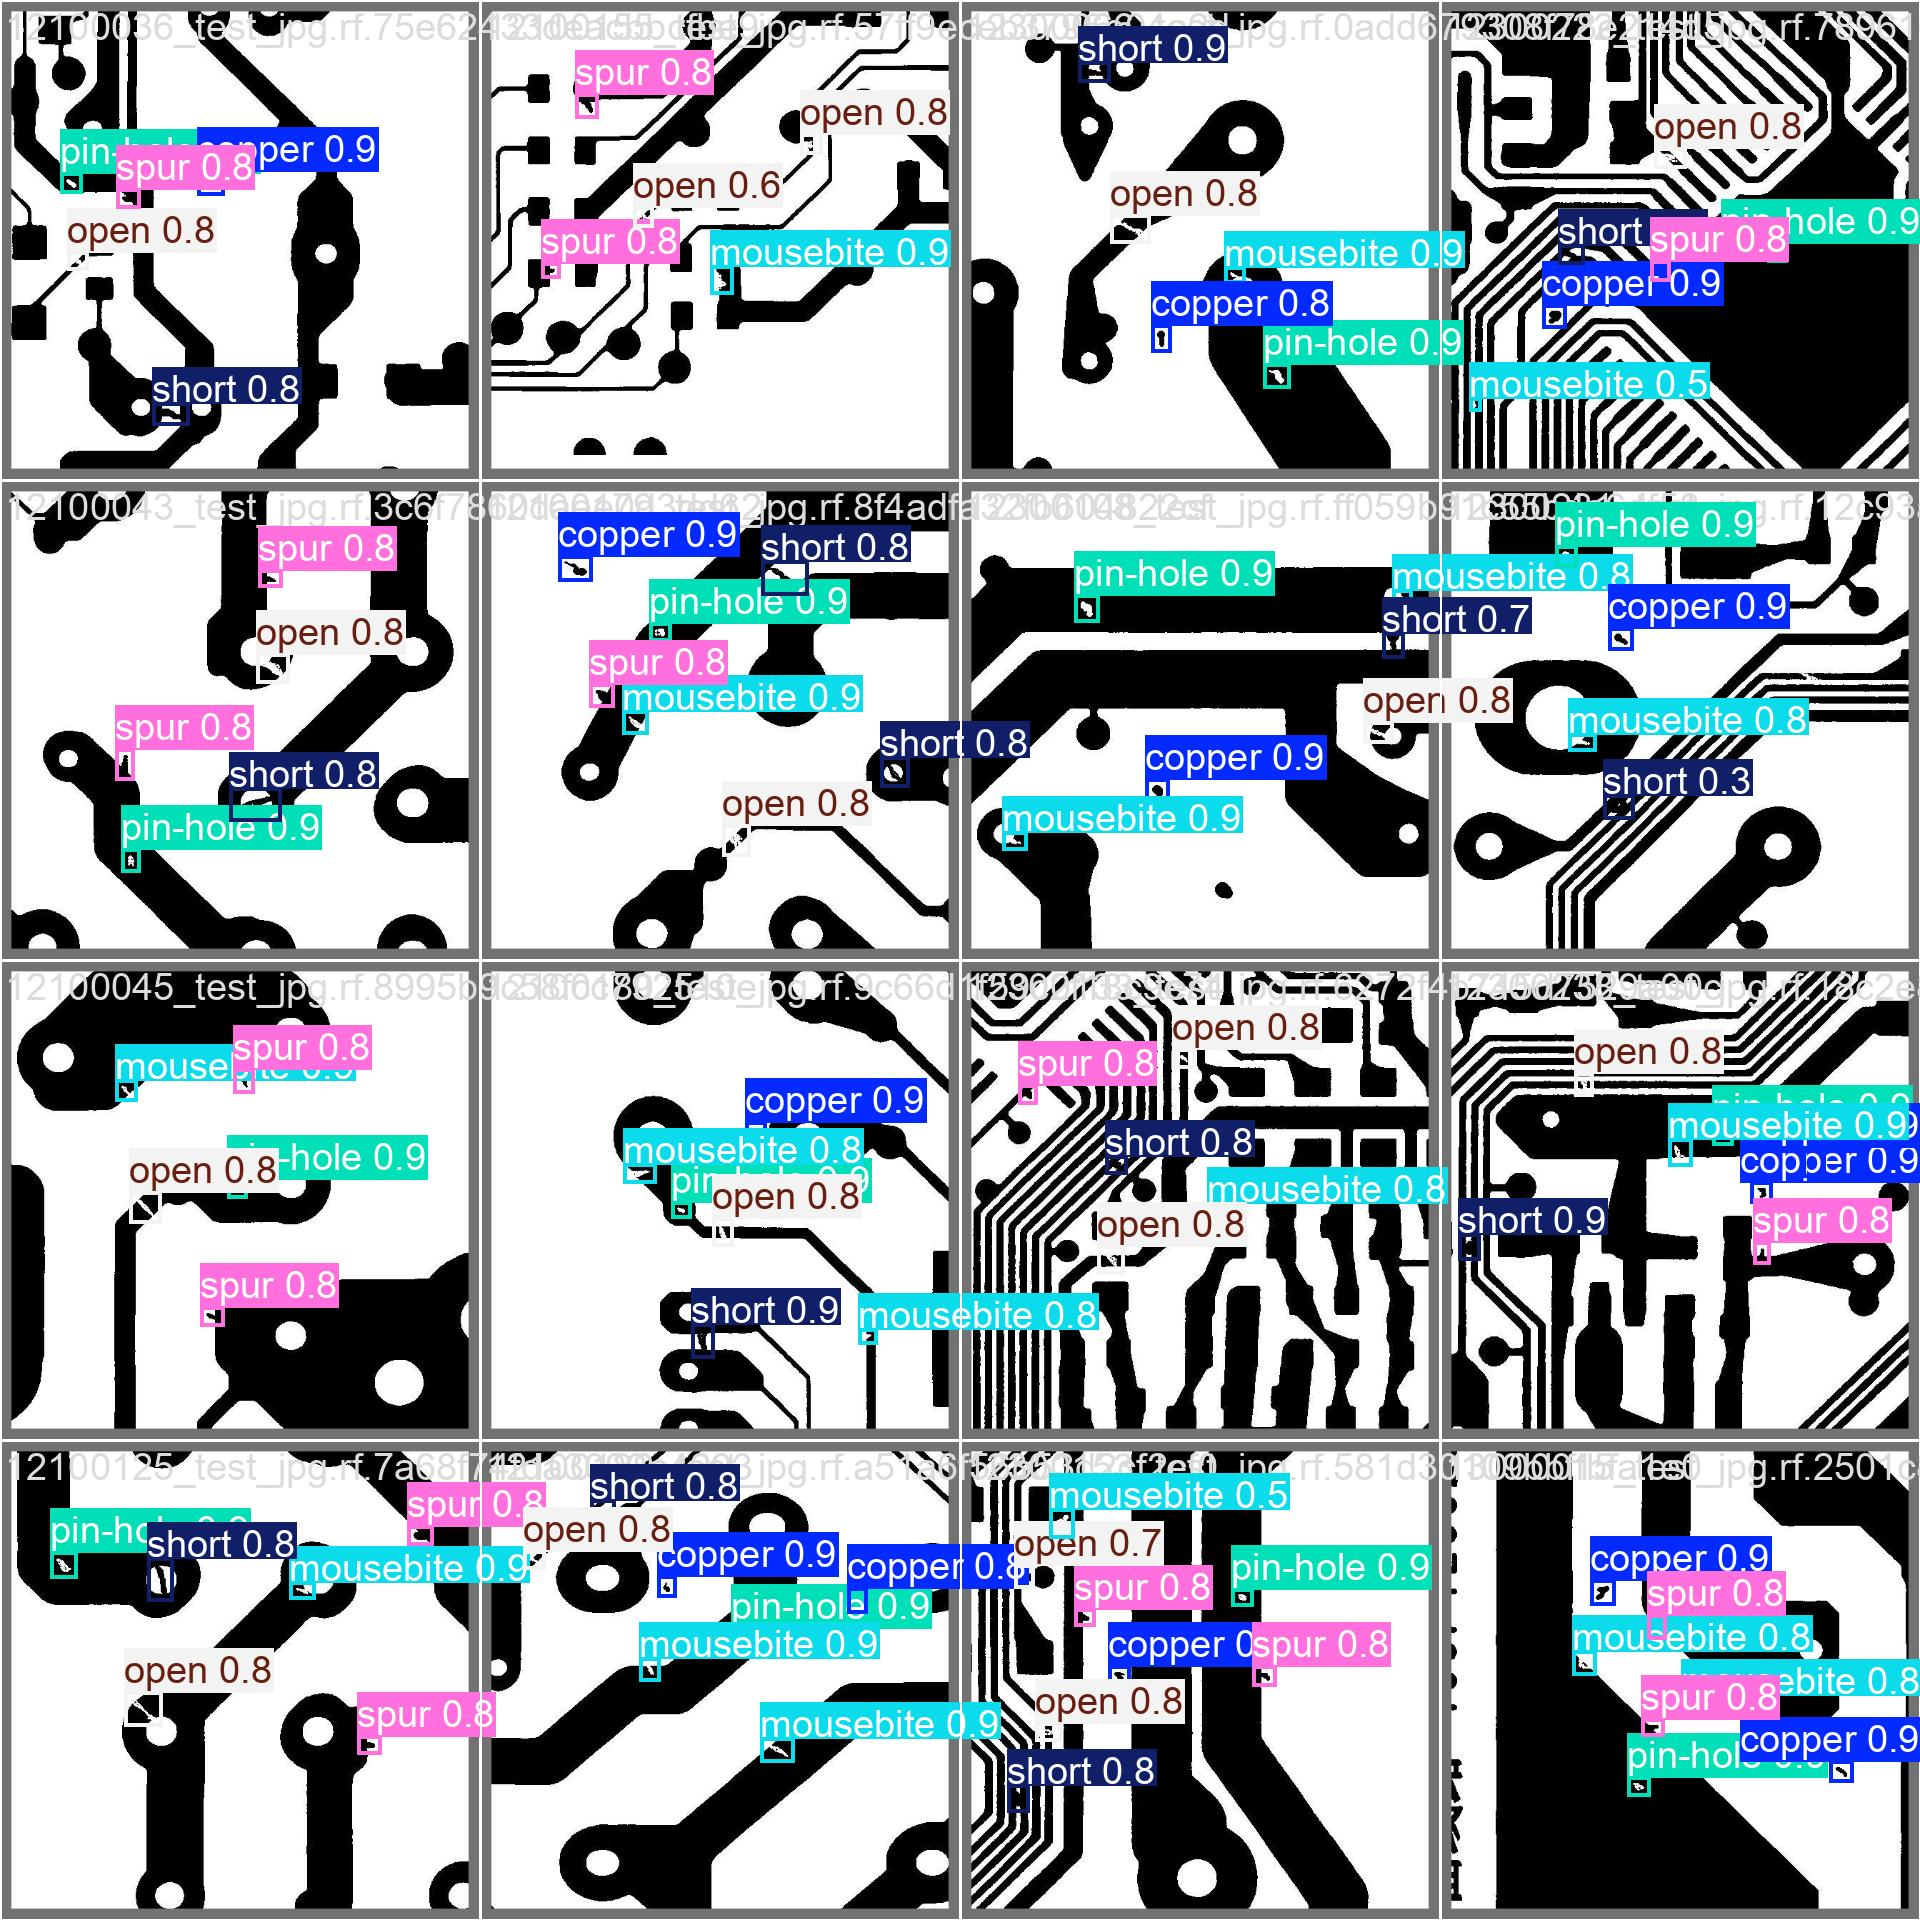

In [14]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/val/*.jpg'):
  display(Image(filename=image_path, height=600))
  print("\n")